In [1]:
%matplotlib inline
import sys
from pathlib import Path
import numpy as np
import pandas as pd
import joblib
from scipy.stats import mode
from scipy.special import logsumexp
from scipy.linalg import solve_triangular
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

In [2]:
current_dir = Path.cwd()
project_root = current_dir.parent
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))
    print("Done")

Done


In [ ]:
from Scripts.gmm import fit_gmm, generate_digit

In [4]:
data_path = project_root / "data"
train_data = pd.read_csv(str(data_path / "mnist_train.csv"), header=None)
test_data = pd.read_csv(str(data_path / "mnist_test.csv"), header=None)

In [5]:
train_data.shape, test_data.shape

((60000, 785), (10000, 785))

In [6]:
train_data.head()

,0,1,2,3,4,5,6,7,8,9,...,775,776,777,778,779,780,781,782,783,784
0,5,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,4,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,9,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [7]:
train_data.columns[10:20]

Index([10, 11, 12, 13, 14, 15, 16, 17, 18, 19], dtype='int64')

In [8]:
train_labels = train_data.iloc[:, 0]
pixels = train_data.iloc[:, 1:]

In [9]:
sample = pixels.iloc[0].to_numpy().reshape(28,28)

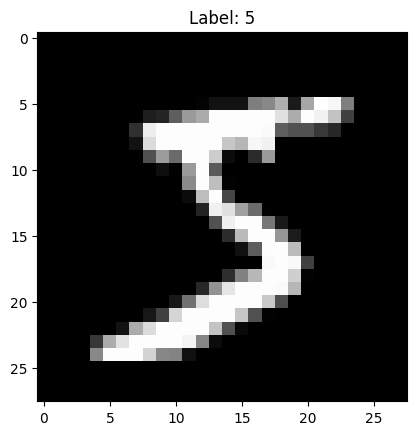

In [10]:
plt.imshow(sample, cmap='gray')
plt.title(f"Label: {train_labels[0]}")
plt.show()

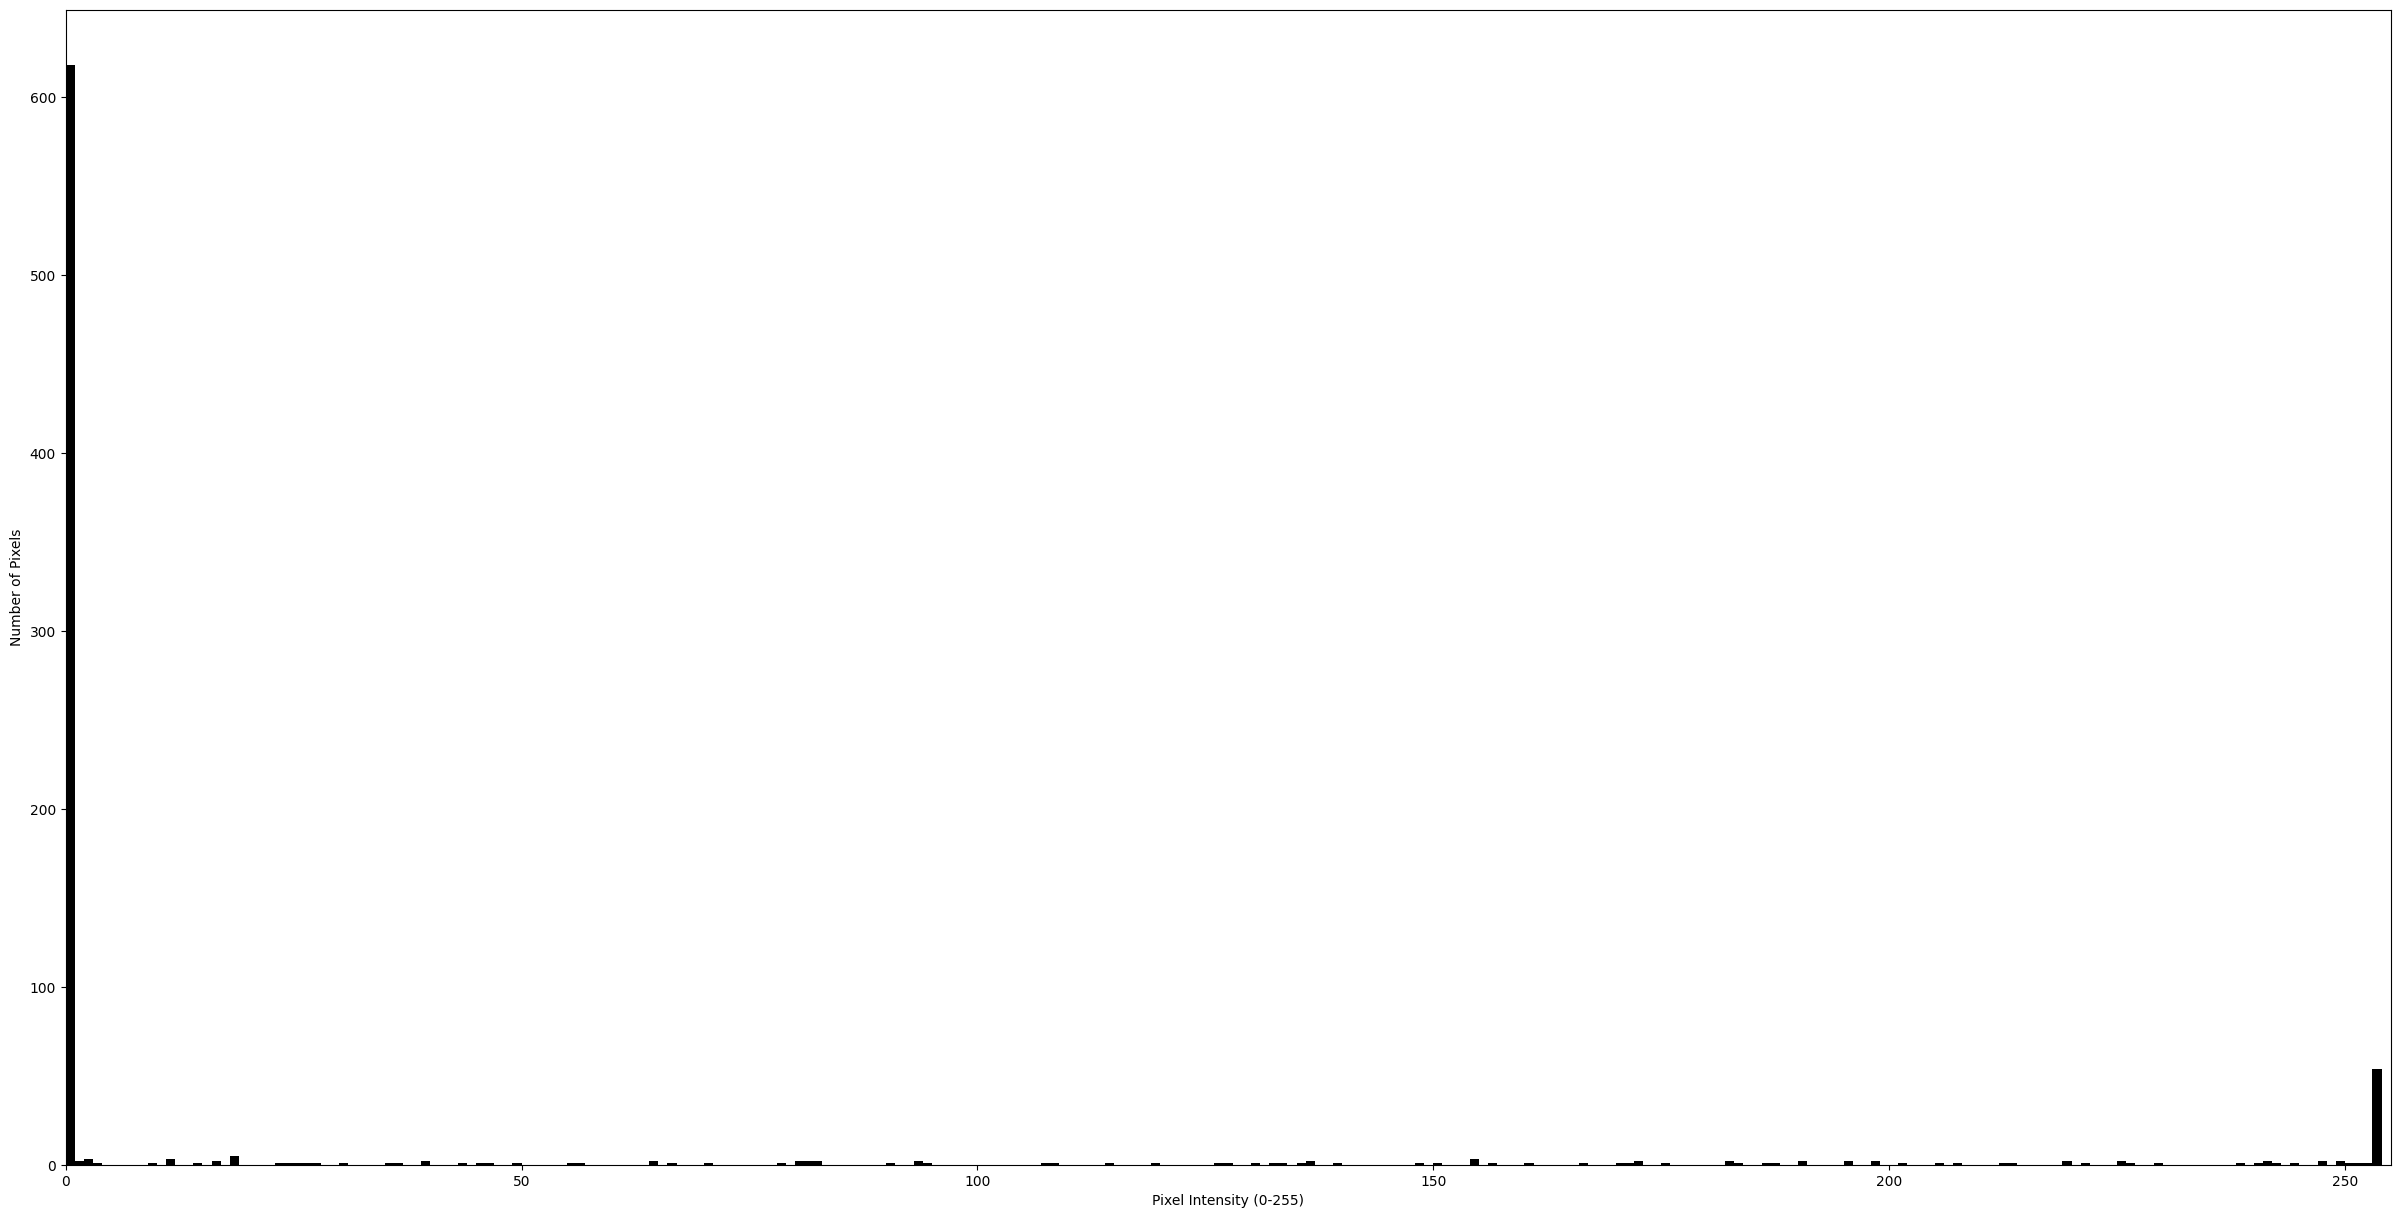

In [11]:
plt.figure(figsize=(30,15))
plt.hist(pixels.iloc[0].values, bins=256, range=(0, 256), color='black')
plt.xlim(0, 255)
plt.xlabel("Pixel Intensity (0-255)")
plt.ylabel("Number of Pixels")
plt.show()

In [12]:
scaler = StandardScaler()
pixels_scaled = scaler.fit_transform(pixels.to_numpy())

In [13]:
means, covs, priors, pca = fit_gmm(X_raw=pixels_scaled, K=40, iterations=100)

KeyboardInterrupt: 

In [18]:
pca = PCA(n_components=0.95, svd_solver='full')
X_reduced = pca.fit_transform(pixels.to_numpy())
print(f"Original features: 784 | Reduced features for 95% variance: {pca.n_components_}")

Original features: 784 | Reduced features for 95% variance: 154


In [15]:
path = project_root / "data"

In [ ]:
# Save GMM parameters (numpy arrays)
np.savez(str(path / "gmm_parameters.npz"), 
         means=means, 
         covs=covs, 
         priors=priors)

# Save the PCA model (needed to "un-compress" generated samples)
# joblib is better than pickle for large arrays inside sklearn objects
joblib.dump(pca, str(path / 'pca_model.joblib'))

print("Model saved successfully!")


Model saved successfully!


In [16]:
# Load PCA and Mapping
pca = joblib.load(str(path / 'pca_model.joblib'))

# Load GMM Arrays
gmm_data = np.load(str(path / "gmm_parameters.npz"))
means = gmm_data['means']
covs = gmm_data['covs']
priors = gmm_data['priors']

print("Model loaded! Ready to generate.")

Model loaded! Ready to generate.


In [17]:
pca = PCA(n_components=0.95, svd_solver='full')
X_reduced = pca.fit_transform(pixels_scaled)

In [19]:
def bayes_probs(X, means, covs, priors):
    """Calculates responsibilities (E-step) safely for high dimensions."""
    N, D = X.shape
    K = len(priors)
    log_probs = np.zeros((N, K))
    
    for k in range(K):
        # 1. Regularize and Decompose
        L = np.linalg.cholesky(covs[k] + np.eye(D) * 1e-5)
        
        # 2. Log Determinant
        log_det = 2 * np.sum(np.log(np.diag(L)))
        
        # 3. Mahalanobis distance: (x-mu).T @ inv(Sigma) @ (x-mu)
        diff = X - means[k]
        y = solve_triangular(L, diff.T, lower=True)
        exponent = -0.5 * np.sum(np.square(y), axis=0)
        
        # 4. Log Likelihood for this cluster
        log_probs[:, k] = -0.5 * (D * np.log(2 * np.pi) + log_det) + exponent + np.log(priors[k] + 1e-15)

    # 5. Log-Sum-Exp trick to normalize safely
    log_totals = logsumexp(log_probs, axis=1)
    responsibilities = np.exp(log_probs - log_totals[:, np.newaxis])
    
    return responsibilities


In [20]:
responsibilities = bayes_probs(X_reduced, means, covs, priors)
cluster_assignments = np.argmax(responsibilities, axis=1)

cluster_to_digit = {}
cluster_purity = {}

for k in range(40):
    labels_in_k = train_labels[cluster_assignments == k]
    
    if len(labels_in_k) > 0:
        most_common = mode(labels_in_k, keepdims=True) # keepdims ensures it acts like an array
        
        # Accessing the first element safely
        cluster_to_digit[k] = most_common.mode[0]
        cluster_purity[k] = most_common.count[0] / len(labels_in_k)
        
        print(f"Cluster {k:2}: Digit {cluster_to_digit[k]} | Purity: {cluster_purity[k]:.2%}")

Cluster  0: Digit 2 | Purity: 61.05%
Cluster  1: Digit 7 | Purity: 46.58%
Cluster  2: Digit 7 | Purity: 78.45%
Cluster  3: Digit 9 | Purity: 48.16%
Cluster  4: Digit 0 | Purity: 38.39%
Cluster  5: Digit 1 | Purity: 99.13%
Cluster  6: Digit 4 | Purity: 80.82%
Cluster  7: Digit 5 | Purity: 49.93%
Cluster  8: Digit 0 | Purity: 42.27%
Cluster  9: Digit 6 | Purity: 90.48%
Cluster 10: Digit 7 | Purity: 67.81%
Cluster 11: Digit 6 | Purity: 49.40%
Cluster 12: Digit 3 | Purity: 80.26%
Cluster 13: Digit 9 | Purity: 34.27%
Cluster 14: Digit 5 | Purity: 55.94%
Cluster 15: Digit 2 | Purity: 100.00%
Cluster 16: Digit 1 | Purity: 98.72%
Cluster 17: Digit 7 | Purity: 68.38%
Cluster 18: Digit 7 | Purity: 84.05%
Cluster 19: Digit 8 | Purity: 74.55%
Cluster 20: Digit 2 | Purity: 90.59%
Cluster 21: Digit 5 | Purity: 43.99%
Cluster 22: Digit 7 | Purity: 93.94%
Cluster 23: Digit 2 | Purity: 61.71%
Cluster 24: Digit 0 | Purity: 61.04%
Cluster 25: Digit 3 | Purity: 55.42%
Cluster 26: Digit 7 | Purity: 95.70%


In [21]:
def generate_digit(target_digit, means, covs, cluster_map, purity_map, pca):
    # Find all clusters assigned to this digit with high purity
    candidates = [k for k, v in cluster_map.items() 
                  if v == target_digit and purity_map[k] > 0.8]
    
    if not candidates:
        # Fallback to the most pure cluster if none exceed 80%
        candidates = [k for k, v in cluster_map.items() if v == target_digit]
        candidates = [sorted(candidates, key=lambda x: purity_map[x])[-1]]

    # Pick a random cluster from the specialized candidates
    chosen_k = np.random.choice(candidates)
    
    # 1. Sample from the Gaussian in the REDUCED space
    sample_latent = np.random.multivariate_normal(means[chosen_k], covs[chosen_k])
    
    # 2. Project back to 784-pixel space
    sample_pixels = pca.inverse_transform(sample_latent.reshape(1, -1))
    
    return sample_pixels

In [135]:
target_digit = 8
generated_digit = generate_digit(target_digit=target_digit, means=means, covs=covs, cluster_map=cluster_to_digit, purity_map=cluster_purity, pca=pca)

In [136]:
generated_digit.shape

(1, 784)

In [137]:
ori_generated_digit = scaler.inverse_transform(generated_digit).reshape((28, 28))

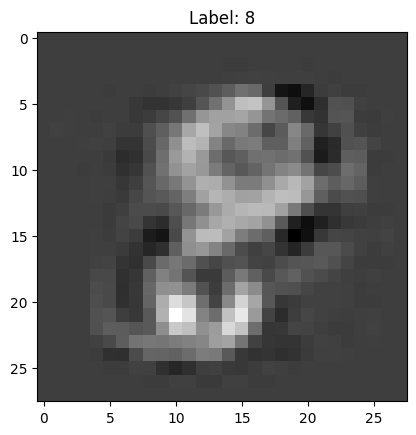

In [138]:
plt.imshow(ori_generated_digit, cmap='gray')
plt.title(f"Label: {target_digit}")
plt.show()